Description: Optimization of SVM model for 1 protein marker ca125
Developed by: Johan A. Yapo
Date: June 2nd 2025

# Set Up

## Imports

In [80]:
import pandas as pd
import numpy as np
import os
from collections import Counter
import matplotlib.pyplot as plt
from sklearn import model_selection

from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import seaborn as sns
import csv

## Seeds and Paths

In [81]:
RNG_SEED = 8
np.random.seed(RNG_SEED)
curr_dir = os.getcwd()
DATA_PATH = os.path.join(os.path.dirname(curr_dir), 'Data')
MODELS_PATH = os.path.join(os.path.dirname(curr_dir), 'Models')
WEIGHTS_PATH = os.path.join(os.path.dirname(curr_dir), 'Weights')
ASSETS_PATH = os.path.join(os.path.dirname(curr_dir), 'Assets')
RESULTS_PATH = os.path.join(os.path.dirname(curr_dir), 'Results')

# loading train and test datasets

In [82]:
df_train = pd.read_csv(os.path.join(DATA_PATH, 'ca_125_train.csv'))
df_test = pd.read_csv(os.path.join(DATA_PATH, 'ca_125_test.csv'))
print(df_train.shape, df_test.shape)

(12, 8) (3, 8)


In [83]:
print("train:\n", df_train, "\n\ntest:\n", df_test)

train:
          Type  Type_float (ng/ml) Class_Multimodal       Rsol            Rp  \
0   300 ng/ml               300.0        High Risk  33.670000  8.990000e+05   
1   330 ng/ml               330.0        High Risk  57.720000  3.366667e+06   
2   240 ng/ml               240.0        High Risk  50.586667  1.508000e+07   
3   150 ng/ml               150.0         Low Risk  45.126667  3.481333e+06   
4           0                 0.0          Normal   40.766667  1.423667e+06   
5   360 ng/ml               360.0        High Risk  50.533333  3.340000e+06   
6   180 ng/ml               180.0         Low Risk  49.880000  6.853333e+06   
7   106 ng/ml               106.0         Low Risk  32.970000  1.130333e+06   
8   200 ng/ml               200.0        High Risk  39.833333  1.302000e+06   
9    10 ng/ml                10.0          Normal   40.953333  1.150000e+06   
10   90 ng/ml                90.0          Normal   34.123333  9.620000e+05   
11   57 ng/ml                57.0          N

# Pre-processing

In [ ]:
# Drop non-numerical and target column from features
X_train = df_train.drop(columns=["Type", "Class_Multimodal"])
X_test = df_test.drop(columns=["Type", "Class_Multimodal"])

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(df_train["Class_Multimodal"])
y_test = le.transform(df_test["Class_Multimodal"])

# model for skf: scaling + classification
svc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1, gamma="scale"))
])

# Stratified K-Fold
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RNG_SEED)


In [90]:
print(y_train)

[0 0 0 1 2 0 1 1 0 2 2 2]


## Visualize stratifiedkfold to determine optimal number

c:\Users\joeya\Documents\pancreatic_cancer_SVM\env\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


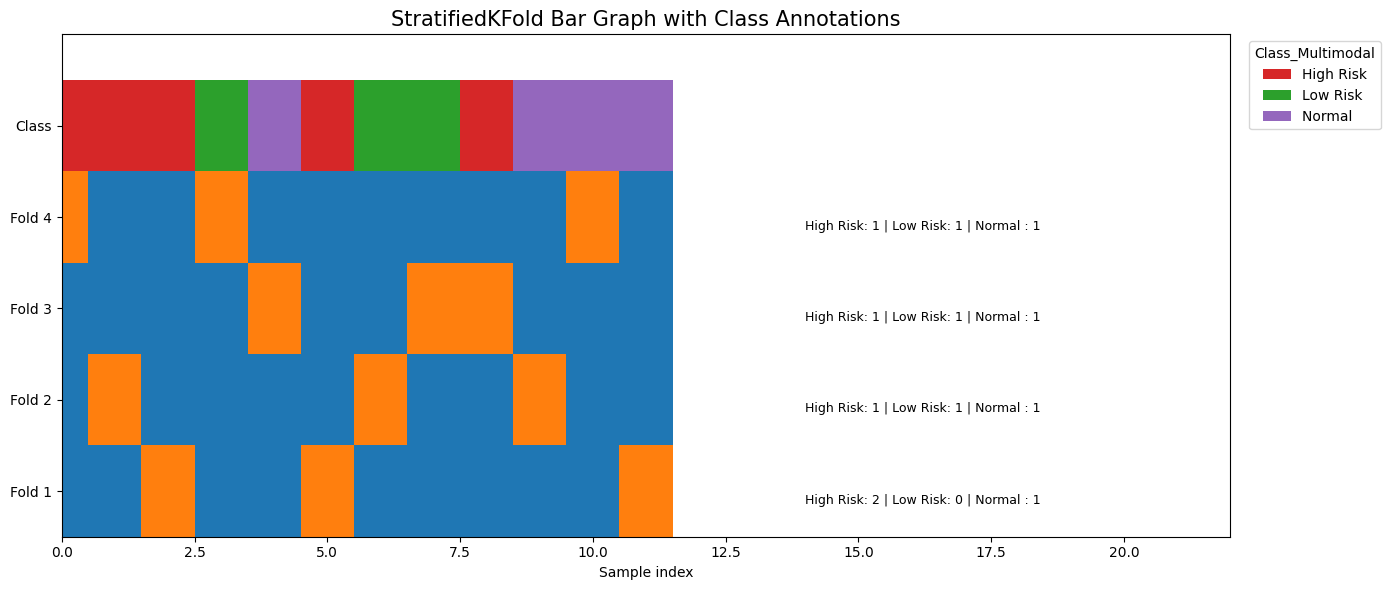

In [86]:
# Redefine custom colormaps in case of kernel reset
from matplotlib.colors import ListedColormap

cmap_cv = ListedColormap(["#1f77b4", "#ff7f0e"])  # Train = blue, Test = orange
cmap_data = ListedColormap(["#d62728", "#2ca02c", "#9467bd"])  # For class labels


def plot_skf_bargraph_with_class_annotations(cv, X_train, y_train, label_encoder, n_splits=5):
    """Bar graph visualization for StratifiedKFold splits with class annotations."""
    fig, ax = plt.subplots(figsize=(14, 6))

    for ii, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
        bar = np.full(len(X_train), np.nan)
        bar[train_idx] = 0
        bar[test_idx] = 1

        ax.bar(range(len(X_train)), [1] * len(X_train), bottom=ii,
               color=[cmap_cv(int(val)) if not np.isnan(val) else 'white' for val in bar],
               edgecolor='none', width=1.0)

        # Compute and annotate class distribution for the test set
        y_test = y_train[test_idx]
        counts = Counter(y_test)
        total = len(test_idx)
        class_labels = label_encoder.classes_
        annotation = " | ".join(
            f"{class_labels[cls]}: {counts.get(cls, 0)}" for cls in range(len(class_labels))
        )
        ax.text(len(X_train) + 2, ii + 0.4, annotation, va='center', fontsize=9)

    # Add class labels as final bar
    class_colors = [cmap_data(val) for val in y_train]
    ax.bar(range(len(X_train)), [1] * len(X_train), bottom=n_splits,
           color=class_colors, edgecolor='none', width=1.0)

    # Formatting
    ax.set_yticks(np.arange(n_splits + 1) + 0.5)
    ax.set_yticklabels([f"Fold {i+1}" for i in range(n_splits)] + ["Class"])
    ax.set_ylim(0, n_splits + 1.5)
    ax.set_xlim(0, len(X_train) + 10)
    ax.set_xlabel("Sample index")
    ax.set_title("StratifiedKFold Bar Graph with Class Annotations", fontsize=15)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=cmap_data(i), label=label) for i, label in enumerate(label_encoder.classes_)]
    ax.legend(handles=legend_elements, title="Class_Multimodal", bbox_to_anchor=(1.01, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

# Display the annotated plot
plot_skf_bargraph_with_class_annotations(skf, X_train, y_train, le, n_splits=4)

# 1) Training with 5-stratified k-fold

In [99]:

# Stratified K-Fold
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RNG_SEED)

#  Evaluate with cross_val_score

scores = cross_val_score(svc_pipeline, X_train, y_train, cv=skf, scoring="accuracy")

svc_pipeline.fit(X_train, y_train)

print("Cross-validated accuracy scores:", scores)
print("Mean accuracy:", np.mean(scores))



Cross-validated accuracy scores: [0.33333333 0.66666667 0.66666667 0.66666667]
Mean accuracy: 0.5833333333333333


c:\Users\joeya\Documents\pancreatic_cancer_SVM\env\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


# 2) Train model without any Cross-validation

In [ ]:
# Generate predictions on the training set itself

le_train = LabelEncoder()
le_train.fit(df_train["Class_Multimodal"])
y_train = le_train.transform(df_train["Class_Multimodal"])

svc_pipeline_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=8))
])

svc_pipeline_2.fit(X_train, y_train)
y_pred_train = svc_pipeline_2.predict(X_train)


# Evaluate on the same training set (since no CV is used here)
report = classification_report(y_train, y_pred_train, target_names=le_train.classes_, output_dict=False)
print(report)

              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00         5
    Low Risk       1.00      0.67      0.80         3
     Normal        0.80      1.00      0.89         4

    accuracy                           0.92        12
   macro avg       0.93      0.89      0.90        12
weighted avg       0.93      0.92      0.91        12



# Test both on test dataset and generate confusion matrices

In [101]:
#Evaluate model 1 on the test set
y_pred_test1 = svc_pipeline.predict(X_test)
test_report1 = classification_report(y_test, y_pred_test, target_names=le_train.classes_, output_dict=False)

# Evaluate model 2 on the test set

y_pred_test2 = svc_pipeline_2.predict(X_test)
test_report2 = classification_report(y_test, y_pred_test, target_names=le_train.classes_, output_dict=False)

print(test_report1 + "\n\n" + test_report2)

              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00         1
    Low Risk       0.00      0.00      0.00         1
     Normal        0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3


              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00         1
    Low Risk       0.00      0.00      0.00         1
     Normal        0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



c:\Users\joeya\Documents\pancreatic_cancer_SVM\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\joeya\Documents\pancreatic_cancer_SVM\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\joeya\Documents\pancreatic_cancer_SVM\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

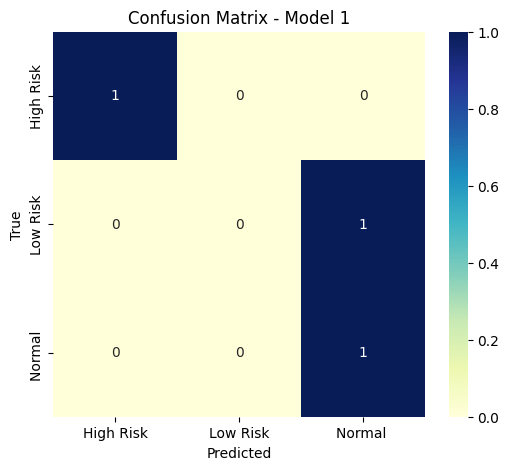

In [110]:
# Plot confusion matrix for model 1 and model 2
class_names = le_train.classes_

cm1 = confusion_matrix(y_test, y_pred_test1, labels=[0, 1, 2])
cm2 = confusion_matrix(y_test, y_pred_test2, labels=[0, 1, 2])

plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, cmap='YlGnBu', fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Model 1")
plt.show()

